In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit


In [2]:
from dd_kable_analysis.config_loader import load_config
from dd_kable_analysis.data_io import (
    get_confounds_data,
    get_subids_bids_dir,
    load_tsv_data,
    resolve_file,
)


# Checking this over with Josh

TBD:  I need to also save out the subjective values of the chosen and unchosen!  We won't be using these right away, but may need them later on.

In [3]:
# ---------------------------------------------------------
# Example assumptions about your dataframe:
#
# df["amount"]       = LL reward amount
# df["Delay"]        = delay for LL option
# df["choseAccept"]  = 1 if LL chosen, 0 if SS chosen
#
# Immediate option:
# SS = $20 now
# ---------------------------------------------------------

SS_AMOUNT = 20


# =========================================================
# Hyperbolic discounting model
# =========================================================


def subjective_value(amount, delay, k):
    """
    Hyperbolic subjective value of delayed reward.
    """
    return amount / (1 + k * delay)


# =========================================================
# Negative log likelihood
# =========================================================


def neg_log_likelihood(params, amount, delay, choices):
    """
    params[0] = log(k)
    params[1] = log(beta)

    choices:
        1 = chose LL
        0 = chose SS
    """

    log_k, log_beta = params

    # Constrain parameters positive
    k = np.exp(log_k)
    beta = np.exp(log_beta)

    # Compute subjective values
    sv_ll = subjective_value(amount, delay, k)
    sv_ss = SS_AMOUNT

    # Softmax choice probability
    p_choose_ll = expit(beta * (sv_ll - sv_ss))

    # Numerical stability
    eps = 1e-10
    p_choose_ll = np.clip(p_choose_ll, eps, 1 - eps)

    # Log likelihood
    loglik = choices * np.log(p_choose_ll) + (1 - choices) * np.log(1 - p_choose_ll)

    return -np.sum(loglik)


# =========================================================
# Fit one subject
# =========================================================


def fit_subject(df_sub):

    amount = df_sub['amount'].values
    delay = df_sub['Delay'].values
    choices = df_sub['choseAccept'].values

    # Initial guesses
    init_params = np.array(
        [
            np.log(0.01),  # k
            np.log(1.0),  # beta
        ]
    )

    result = minimize(
        neg_log_likelihood,
        init_params,
        args=(amount, delay, choices),
        method='L-BFGS-B',
    )

    log_k_hat, log_beta_hat = result.x

    k_hat = np.exp(log_k_hat)
    beta_hat = np.exp(log_beta_hat)

    return k_hat, beta_hat


def compute_trialwise_measures(df_sub, k_hat):
    """
    Compute trial-wise subjective value measures.

    Parameters
    ----------
    df_sub : pandas.DataFrame
        Data for one subject.

    k_hat : float
        Estimated discounting parameter.

    Returns
    -------
    pandas.DataFrame
        Copy of dataframe with added variables.
    """

    temp = df_sub.copy()

    # -----------------------------------------------------
    # Subjective value of delayed option
    # -----------------------------------------------------

    sv_ll = subjective_value(
        temp['amount'].values,
        temp['Delay'].values,
        k_hat,
    )

    # -----------------------------------------------------
    # Subjective value of immediate option
    # -----------------------------------------------------

    sv_ss = np.full(len(temp), SS_AMOUNT)

    # -----------------------------------------------------
    # Decision value
    # -----------------------------------------------------

    dv = sv_ll - sv_ss

    # -----------------------------------------------------
    # Chosen / unchosen values
    # -----------------------------------------------------

    chose_ll = temp['choseAccept'].values.astype(bool)

    sv_chosen = np.where(chose_ll, sv_ll, sv_ss)
    sv_unchosen = np.where(chose_ll, sv_ss, sv_ll)

    # -----------------------------------------------------
    # Store outputs
    # -----------------------------------------------------

    temp['SV_LL'] = sv_ll
    temp['SV_SS'] = sv_ss
    temp['DV'] = dv
    temp['SV_chosen'] = sv_chosen
    temp['SV_unchosen'] = sv_unchosen

    return temp

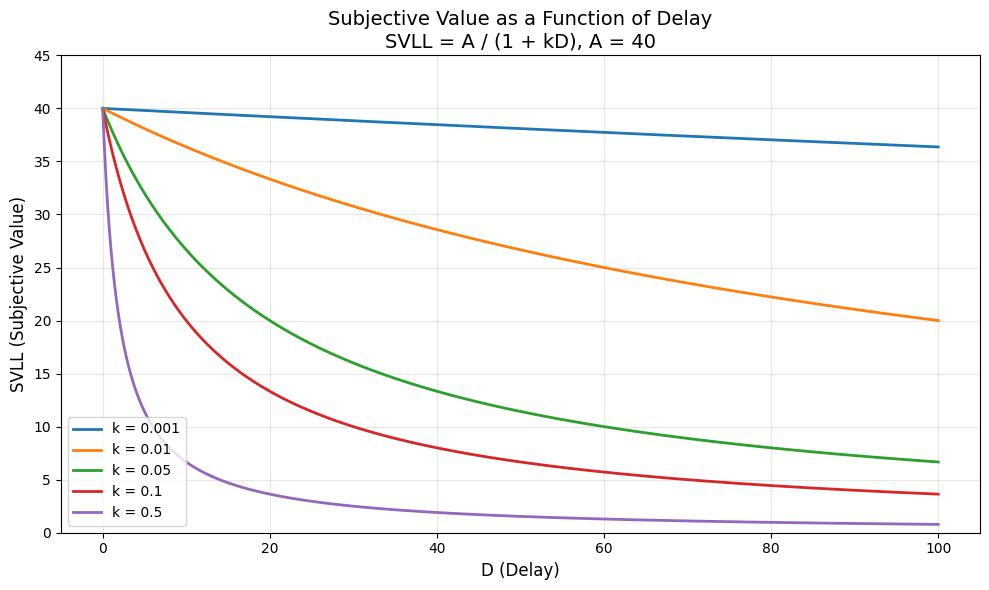

In [31]:
# Fix A at 40
A = 40

# Create a range of D values
D = np.linspace(0, 100, 1000)

# Different k values to plot
k_values = [0.001, 0.01, 0.05, 0.1, 0.5]

# Create the plot
plt.figure(figsize=(10, 6))

for k in k_values:
    SVLL = A / (1 + k * D)
    plt.plot(D, SVLL, label=f'k = {k}', linewidth=2)

plt.xlabel('D (Delay)', fontsize=12)
plt.ylabel('SVLL (Subjective Value)', fontsize=12)
plt.title(
    'Subjective Value as a Function of Delay\nSVLL = A / (1 + kD), A = 40', fontsize=14
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, A + 5)
plt.tight_layout()
plt.show()

In [4]:
cfg = load_config()

good_subs_csv = cfg.subject_lists / 'initial_qa_pass_subjects_runs.csv'
good_subs = pd.read_csv(good_subs_csv)
good_subs

,sub_id,session,run
0,dmp0011,scan1,1
1,dmp0011,scan1,2
2,dmp0011,scan1,3
3,dmp0011,scan1,4
4,dmp0019,scan1,1
...,...,...,...
449,dmp1271,scan1,4
450,dmp1291,scan1,1
451,dmp1291,scan1,2
452,dmp1291,scan1,3


In [5]:
all_behav = []

for row in good_subs.itertuples(index=False):
    sub_id = row.sub_id
    session = row.session
    run = row.run
    behav_file = resolve_file(cfg, sub_id, session, run, 'behav')
    behav_data = load_tsv_data(behav_file)
    behav_data['sub_id'] = sub_id
    behav_data['run'] = run
    all_behav.append(behav_data)

In [7]:
all_behav_df = pd.concat(all_behav)
all_behav_df

,onset,duration,amount,Delay,choseAccept,RT,choseRight,sub_id,run
0,15.822,4,66,58,1.0,1.993,1.0,dmp0011,1
1,24.855,4,39,95,0.0,1.024,0.0,dmp0011,1
2,32.888,4,69,172,0.0,1.071,0.0,dmp0011,1
3,42.937,4,23,42,0.0,1.101,0.0,dmp0011,1
4,56.987,4,77,142,1.0,1.739,1.0,dmp0011,1
...,...,...,...,...,...,...,...,...,...
25,264.904,4,64,89,1.0,1.031,1.0,dmp1291,4
26,272.937,4,41,174,0.0,2.377,0.0,dmp1291,4
27,282.970,4,76,161,1.0,1.414,1.0,dmp1291,4
28,299.003,4,33,103,0.0,1.914,0.0,dmp1291,4


# Trying to assess if there are subjects with weird data
Specifically trying to figure out why future subjective value models land on the intialization points so frequently.

/tmp/ipykernel_16130/940951970.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_curves = df.groupby(['sub_id', 'delay_bin'])['choose_LL'].mean().reset_index()


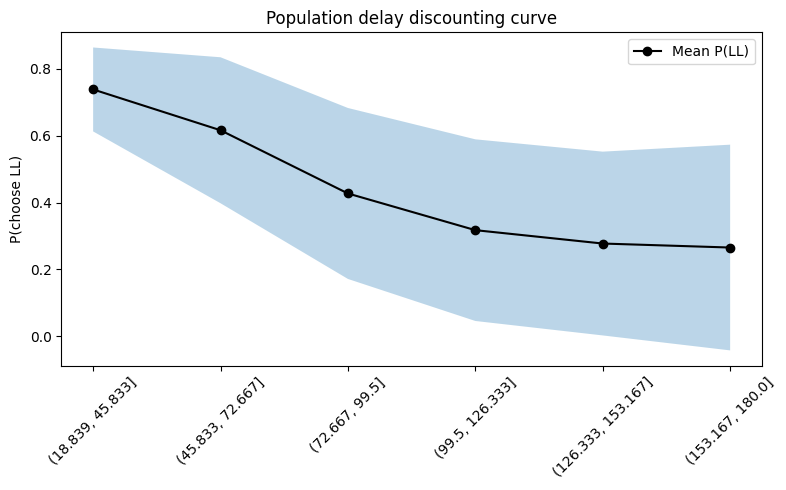

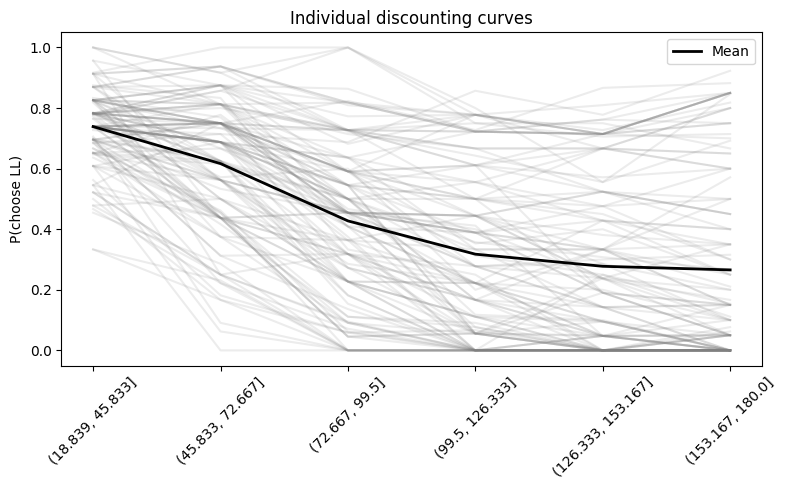

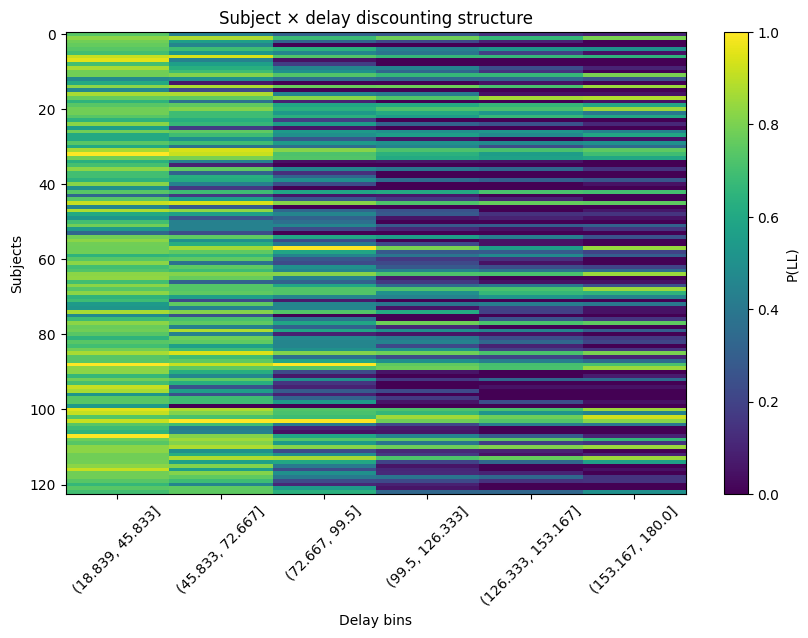

In [57]:
# ---------------------------------------------------------
# 0. COPY AND CLEAN DATA
# ---------------------------------------------------------
df = all_behav_df.copy()

# Drop missing critical fields (prevents silent NaN propagation)
df = df.dropna(subset=['Delay', 'choseAccept'])

# Convert choice to binary numeric (0 = SS, 1 = LL)
df['choose_LL'] = df['choseAccept'].astype(int)


# ---------------------------------------------------------
# 1. BIN DELAY (this turns continuous delay into interpretable groups)
# ---------------------------------------------------------
# We bin delays so we can compute choice proportions per delay range
df['delay_bin'] = pd.cut(df['Delay'], bins=6)


# ---------------------------------------------------------
# 2. COMPUTE SUBJECT-LEVEL DISCOUNTING CURVES
# ---------------------------------------------------------
# For each subject AND each delay bin:
# compute P(choose LL)
sub_curves = df.groupby(['sub_id', 'delay_bin'])['choose_LL'].mean().reset_index()


# ---------------------------------------------------------
# 3. CONVERT TO MATRIX FORM (subjects × delay bins)
# ---------------------------------------------------------
# Rows = subjects
# Columns = delay bins
# Values = P(LL)
curve_matrix = sub_curves.pivot(index='sub_id', columns='delay_bin', values='choose_LL')


# ---------------------------------------------------------
# 4. PLOT 1: POPULATION MEAN + VARIABILITY
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))

mean_curve = curve_matrix.mean(axis=0)
std_curve = curve_matrix.std(axis=0)

x = np.arange(len(mean_curve))

# Mean discounting curve across subjects
plt.plot(x, mean_curve.values, marker='o', color='black', label='Mean P(LL)')

# Variability across subjects (±1 SD)
plt.fill_between(
    x,
    mean_curve.values - std_curve.values,
    mean_curve.values + std_curve.values,
    alpha=0.3,
)

plt.xticks(x, curve_matrix.columns.astype(str), rotation=45)
plt.ylabel('P(choose LL)')
plt.title('Population delay discounting curve')
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 5. PLOT 2: ALL SUBJECTS (SPAGHETTI PLOT + MEAN)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))

# Each subject is a faint gray line
for _, row in curve_matrix.iterrows():
    plt.plot(x, row.values, alpha=0.15, color='gray')

# Overlay mean curve
plt.plot(x, curve_matrix.mean(axis=0).values, color='black', linewidth=2, label='Mean')

plt.xticks(x, curve_matrix.columns.astype(str), rotation=45)
plt.ylabel('P(choose LL)')
plt.title('Individual discounting curves')
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 6. PLOT 3: HEATMAP (BEST OVERALL DIAGNOSTIC)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.imshow(curve_matrix.values, aspect='auto', interpolation='nearest')

plt.colorbar(label='P(LL)')
plt.xlabel('Delay bins')
plt.ylabel('Subjects')
plt.title('Subject × delay discounting structure')

plt.xticks(
    ticks=np.arange(curve_matrix.shape[1]),
    labels=curve_matrix.columns.astype(str),
    rotation=45,
)

plt.show()

In [8]:
results = []

for sub_id, df_sub in all_behav_df.groupby('sub_id'):
    k_hat, beta_hat = fit_subject(df_sub)

    # Subjective value of delayed option
    sv_ll = subjective_value(
        df_sub['amount'].values,
        df_sub['Delay'].values,
        k_hat,
    )

    # Subjective value of sooner option
    sv_ss = np.full(len(df_sub), SS_AMOUNT)

    # Decision value
    dv = sv_ll - sv_ss

    # Choice indicators
    chose_ll = df_sub['choseAccept'].values.astype(bool)

    # Chosen / unchosen subjective values
    sv_chosen = np.where(chose_ll, sv_ll, sv_ss)
    sv_unchosen = np.where(chose_ll, sv_ss, sv_ll)

    temp = df_sub.copy()

    temp['k_hat'] = k_hat
    temp['beta_hat'] = beta_hat

    # Main variable of interest
    temp['SV_LL'] = sv_ll

    # Optional extras
    temp['SV_SS'] = sv_ss
    temp['DV'] = dv
    temp['SV_chosen'] = sv_chosen
    temp['SV_unchosen'] = sv_unchosen

    results.append(temp)

df_out = pd.concat(results, ignore_index=True)

print(df_out.head())

    onset  duration  amount  Delay  choseAccept     RT  choseRight   sub_id  \
0  15.822         4      66     58          1.0  1.993         1.0  dmp0011   
1  24.855         4      39     95          0.0  1.024         0.0  dmp0011   
2  32.888         4      69    172          0.0  1.071         0.0  dmp0011   
3  42.937         4      23     42          0.0  1.101         0.0  dmp0011   
4  56.987         4      77    142          1.0  1.739         1.0  dmp0011   

   run     k_hat  beta_hat      SV_LL  SV_SS        DV  SV_chosen  SV_unchosen  
0    1  0.021838  0.384608  29.118119     20  9.118119  29.118119    20.000000  
1    1  0.021838  0.384608  12.684361     20 -7.315639  20.000000    12.684361  
2    1  0.021838  0.384608  14.507341     20 -5.492659  20.000000    14.507341  
3    1  0.021838  0.384608  11.996569     20 -8.003431  20.000000    11.996569  
4    1  0.021838  0.384608  18.775636     20 -1.224364  18.775636    20.000000  


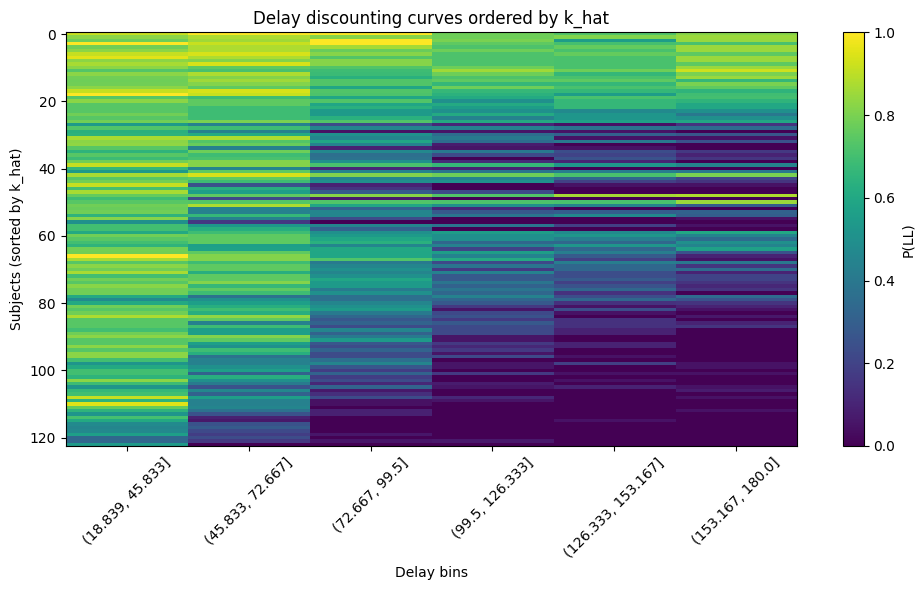

In [59]:
# ---------------------------------------------------------
# 1. GET SUBJECT-LEVEL k ESTIMATES
# ---------------------------------------------------------
# We assume k_hat is already in df_out and (approximately) constant per subject
subject_k = (
    df_out.groupby('sub_id')[
        'k_hat'
    ].first()  # could also use .mean() if you prefer robustness
)

# ---------------------------------------------------------
# 2. BUILD SUBJECT × DELAY-BIN BEHAVIOR MATRIX
# ---------------------------------------------------------
# curve_matrix contains P(LL) per subject per delay bin
# (this should already have been created in your earlier step)
#
# If not, this assumes you already ran:
# df_out['choose_LL'] = df_out['choseAccept'].astype(int)
# df_out['delay_bin'] = pd.cut(df_out['Delay'], bins=6)
# sub_curves = df_out.groupby(['sub_id', 'delay_bin'])['choose_LL'].mean().reset_index()
# curve_matrix = sub_curves.pivot(index='sub_id', columns='delay_bin', values='choose_LL')

# ---------------------------------------------------------
# 3. SORT SUBJECTS BY k_hat
# ---------------------------------------------------------
# This reorders rows so we can see whether k corresponds to behavioral pattern
ordered_subs = subject_k.sort_values().index
curve_sorted = curve_matrix.loc[ordered_subs]

# ---------------------------------------------------------
# 4. PLOT HEATMAP ORDERED BY k_hat
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.imshow(curve_sorted.values, aspect='auto', interpolation='nearest')

plt.colorbar(label='P(LL)')

plt.xlabel('Delay bins')
plt.ylabel('Subjects (sorted by k_hat)')
plt.title('Delay discounting curves ordered by k_hat')

# Label x-axis with actual delay bin labels
plt.xticks(
    ticks=np.arange(curve_sorted.shape[1]),
    labels=curve_sorted.columns.astype(str),
    rotation=45,
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_16130/980043174.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_curves = df.groupby(['sub_id', 'delay_bin'])['choose_LL'].mean().reset_index()


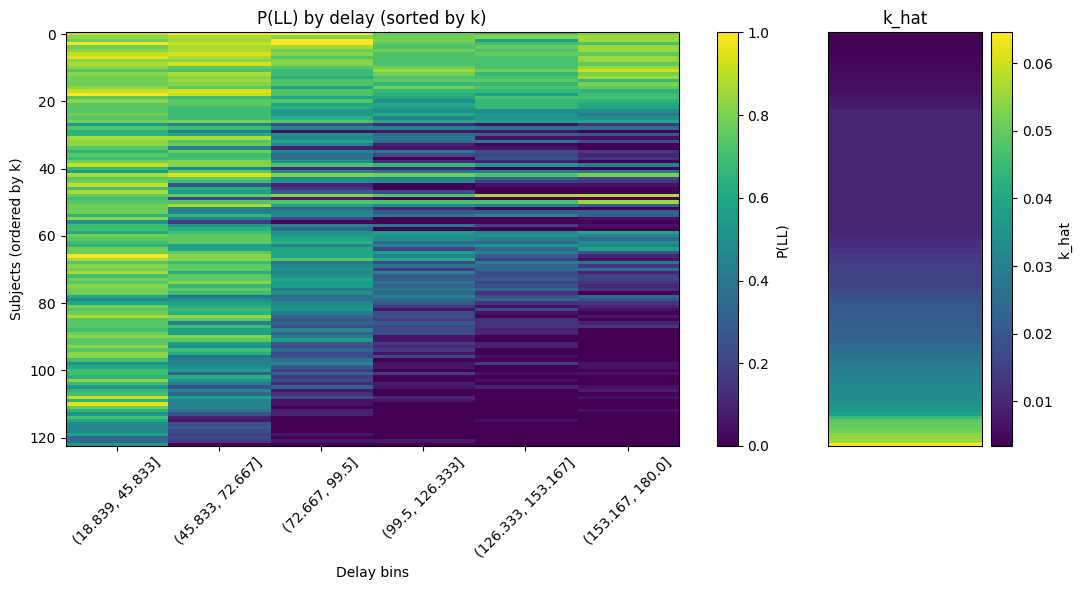

In [62]:
# ---------------------------------------------------------
# 1. SUBJECT-LEVEL k
# ---------------------------------------------------------
subject_k = df_out.groupby('sub_id')['k_hat'].first()

# ---------------------------------------------------------
# 2. BEHAVIOR MATRIX (P(LL))
# ---------------------------------------------------------
df = df_out.copy()
df = df.dropna(subset=['Delay', 'choseAccept'])

df['choose_LL'] = df['choseAccept'].astype(int)
df['delay_bin'] = pd.cut(df['Delay'], bins=6)

sub_curves = df.groupby(['sub_id', 'delay_bin'])['choose_LL'].mean().reset_index()

curve_matrix = sub_curves.pivot(index='sub_id', columns='delay_bin', values='choose_LL')

# ---------------------------------------------------------
# 3. SORT BY k
# ---------------------------------------------------------
ordered_subs = subject_k.sort_values().index
curve_sorted = curve_matrix.loc[ordered_subs]
k_sorted = subject_k.loc[ordered_subs]

# ---------------------------------------------------------
# 4. PLOT HEATMAP + k SIDE BAR
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(11, 6), gridspec_kw={'width_ratios': [4, 1]}
)

# ---------------------------------------------------------
# LEFT: behavior heatmap (P(LL))
# ---------------------------------------------------------
im1 = ax1.imshow(
    curve_sorted.values, aspect='auto', interpolation='nearest', vmin=0, vmax=1
)
ax1.set_title('P(LL) by delay (sorted by k)')
ax1.set_xlabel('Delay bins')
ax1.set_ylabel('Subjects (ordered by k)')

ax1.set_xticks(np.arange(curve_sorted.shape[1]))
ax1.set_xticklabels(curve_sorted.columns.astype(str), rotation=45)

cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('P(LL)')

# ---------------------------------------------------------
# RIGHT: k values
# ---------------------------------------------------------
im2 = ax2.imshow(k_sorted.values.reshape(-1, 1), aspect='auto', cmap='viridis')

ax2.set_title('k_hat')
ax2.set_xticks([])
ax2.set_yticks([])

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('k_hat')

plt.tight_layout()
plt.show()

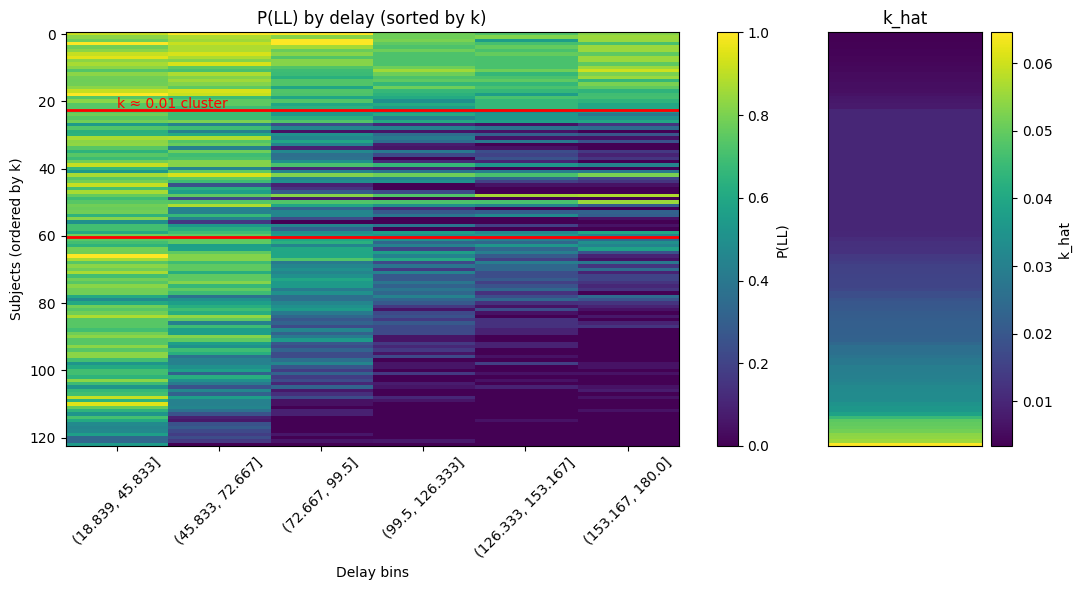

In [63]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(11, 6), gridspec_kw={'width_ratios': [4, 1]}
)

# ---------------------------------------------------------
# LEFT: P(LL) HEATMAP
# ---------------------------------------------------------
im1 = ax1.imshow(
    curve_sorted.values, aspect='auto', interpolation='nearest', vmin=0, vmax=1
)

ax1.set_title('P(LL) by delay (sorted by k)')
ax1.set_xlabel('Delay bins')
ax1.set_ylabel('Subjects (ordered by k)')

ax1.set_xticks(np.arange(curve_sorted.shape[1]))
ax1.set_xticklabels(curve_sorted.columns.astype(str), rotation=45)

plt.colorbar(im1, ax=ax1, label='P(LL)')

# ---------------------------------------------------------
# RIGHT: k values
# ---------------------------------------------------------
im2 = ax2.imshow(k_sorted.values.reshape(-1, 1), aspect='auto', cmap='viridis')

ax2.set_title('k_hat')
ax2.set_xticks([])
ax2.set_yticks([])

plt.colorbar(im2, ax=ax2, label='k_hat')

# ---------------------------------------------------------
# ADD HORIZONTAL LINE FOR k ≈ 0.01 GROUP
# ---------------------------------------------------------
# Identify rows where k rounds to 0.01
k_target = 0.01
mask = np.isclose(k_sorted.values, k_target, atol=1e-3)

# Get row indices of that group
idx = np.where(mask)[0]

if len(idx) > 0:
    # draw top and bottom boundary of the block
    ax1.axhline(idx[0] - 0.5, color='red', linewidth=2)
    ax1.axhline(idx[-1] + 0.5, color='red', linewidth=2)

    # optional label
    ax1.text(0, idx[0], 'k ≈ 0.01 cluster', color='red', fontsize=10, va='bottom')

plt.tight_layout()
plt.show()

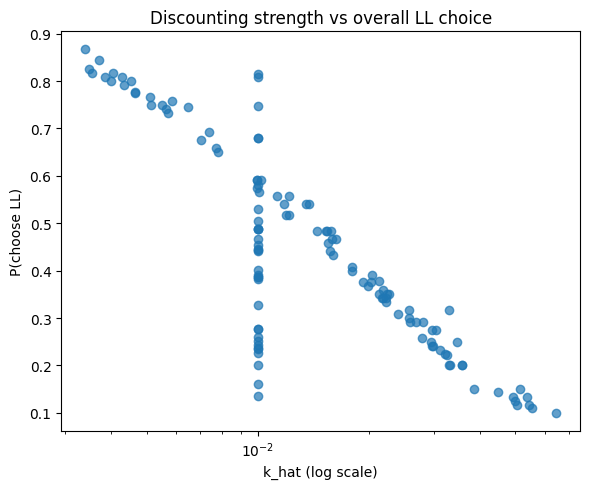

In [64]:
# ---------------------------------------------------------
# 1. SUBJECT-LEVEL k (one value per subject)
# ---------------------------------------------------------
subject_k = df_out.groupby('sub_id')['k_hat'].first()

# ---------------------------------------------------------
# 2. SUBJECT-LEVEL P(LL)
# ---------------------------------------------------------
subject_pLL = df_out.groupby('sub_id')['choseAccept'].mean()

# ---------------------------------------------------------
# 3. ALIGN BOTH MEASURES
# ---------------------------------------------------------
plot_df = pd.DataFrame({'k_hat': subject_k, 'pLL': subject_pLL}).dropna()

# ---------------------------------------------------------
# 4. PLOT k vs P(LL)
# ---------------------------------------------------------
plt.figure(figsize=(6, 5))

plt.scatter(plot_df['k_hat'], plot_df['pLL'], alpha=0.7)

plt.xscale('log')  # important: k is usually log-distributed

plt.xlabel('k_hat (log scale)')
plt.ylabel('P(choose LL)')
plt.title('Discounting strength vs overall LL choice')

plt.tight_layout()
plt.show()

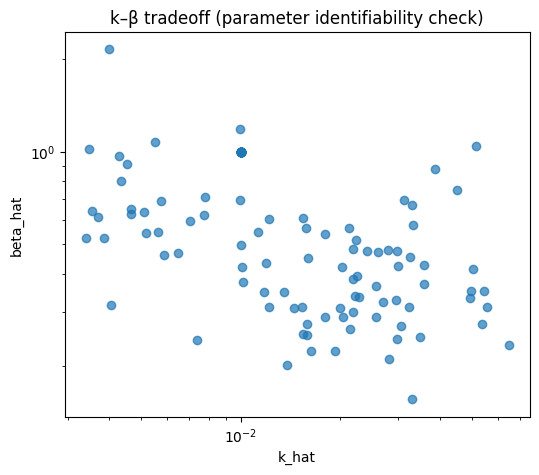

In [65]:
plot_df = df_out.groupby('sub_id')[['k_hat', 'beta_hat']].first()

plt.figure(figsize=(6, 5))
plt.scatter(plot_df['k_hat'], plot_df['beta_hat'], alpha=0.7)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('k_hat')
plt.ylabel('beta_hat')
plt.title('k–β tradeoff (parameter identifiability check)')
plt.show()

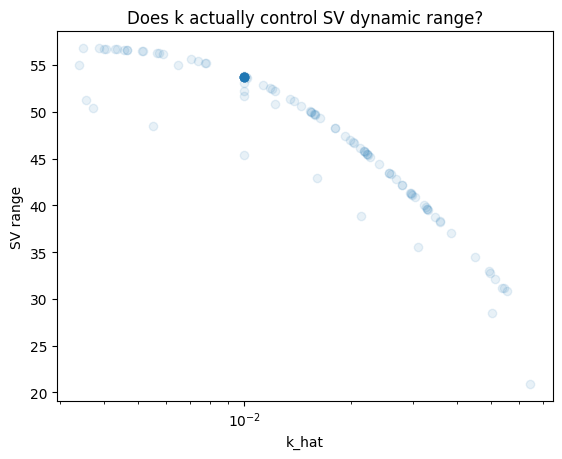

In [67]:
df_out['SV_range'] = (
    df_out['SV_LL'].groupby(df_out['sub_id']).transform(lambda x: x.max() - x.min())
)

subject_sv = df_out.groupby('sub_id')['SV_range'].first()
subject_k = df_out.groupby('sub_id')['k_hat'].first()

plt.scatter(subject_k, subject_sv, alpha=0.1)
plt.xscale('log')
plt.xlabel('k_hat')
plt.ylabel('SV range')
plt.title('Does k actually control SV dynamic range?')
plt.show()

/tmp/ipykernel_16130/1842515811.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_curves = df.groupby(['sub_id', 'delay_bin'])['choose_LL'].mean().reset_index()


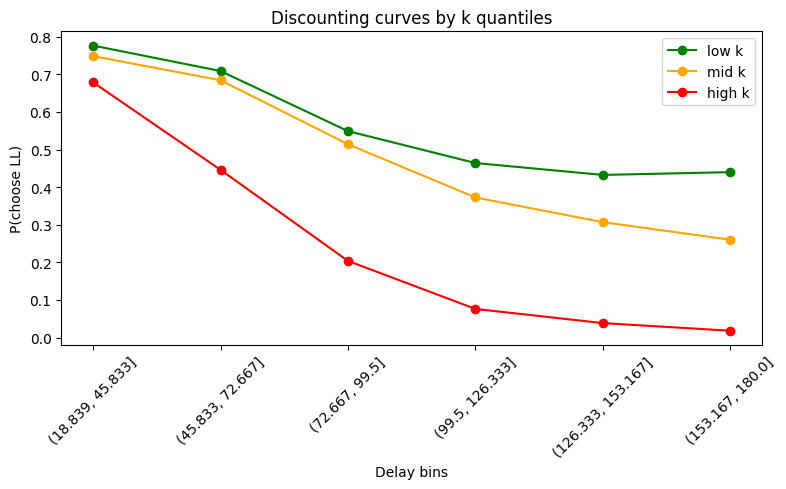

In [60]:
# ---------------------------------------------------------
# 1. PREP: SUBJECT-LEVEL k ESTIMATES
# ---------------------------------------------------------
subject_k = df_out.groupby('sub_id')['k_hat'].first()

# ---------------------------------------------------------
# 2. BUILD BEHAVIOR MATRIX (P(LL) per subject × delay bin)
# ---------------------------------------------------------
df = df_out.copy()

df = df.dropna(subset=['Delay', 'choseAccept'])
df['choose_LL'] = df['choseAccept'].astype(int)
df['delay_bin'] = pd.cut(df['Delay'], bins=6)

sub_curves = df.groupby(['sub_id', 'delay_bin'])['choose_LL'].mean().reset_index()

curve_matrix = sub_curves.pivot(index='sub_id', columns='delay_bin', values='choose_LL')

# ---------------------------------------------------------
# 3. BIN SUBJECTS INTO k QUANTILES
# ---------------------------------------------------------
# This creates groups of subjects based on estimated k
k_quantiles = pd.qcut(subject_k, q=3, labels=['low k', 'mid k', 'high k'])

# Align with curve matrix index
k_groups = k_quantiles.loc[curve_matrix.index]

# ---------------------------------------------------------
# 4. COMPUTE MEAN CURVES PER k GROUP
# ---------------------------------------------------------
group_curves = {}

for g in ['low k', 'mid k', 'high k']:
    group_curves[g] = curve_matrix[k_groups == g].mean(axis=0)

# ---------------------------------------------------------
# 5. PLOT: COMPARISON OF DISCOUNTING CURVES BY k GROUP
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))

x = np.arange(curve_matrix.shape[1])
labels = curve_matrix.columns.astype(str)

for g, color in zip(['low k', 'mid k', 'high k'], ['green', 'orange', 'red']):
    plt.plot(x, group_curves[g].values, marker='o', label=g, color=color)

plt.xticks(x, labels, rotation=45)
plt.ylabel('P(choose LL)')
plt.xlabel('Delay bins')
plt.title('Discounting curves by k quantiles')
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
print(df_out['Delay'].describe())
print(np.sort(df_out['Delay'].unique())[:20])

count    13620.000000
mean        98.363510
std         46.910476
min         19.000000
25%         58.000000
50%         95.000000
75%        139.000000
max        180.000000
Name: Delay, dtype: float64
[19 21 22 23 24 26 27 36 37 38 39 41 42 43 44 52 53 55 57 58]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


(123,)


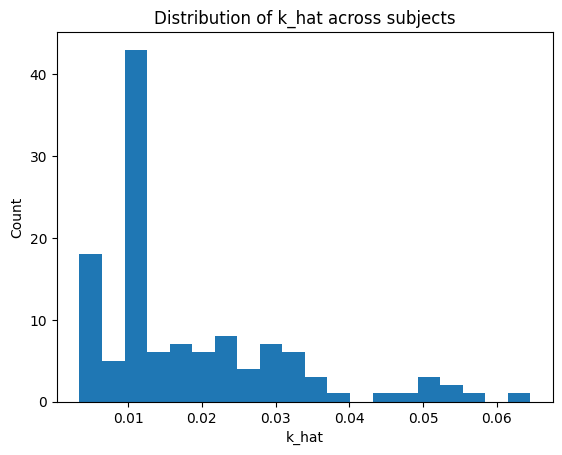

In [21]:
tmp_df = df_out.groupby('sub_id')['k_hat'].first()
print(tmp_df.shape)

plt.figure()
plt.hist(tmp_df, bins=20)
plt.xlabel('k_hat')
plt.ylabel('Count')
plt.title('Distribution of k_hat across subjects')
plt.show()

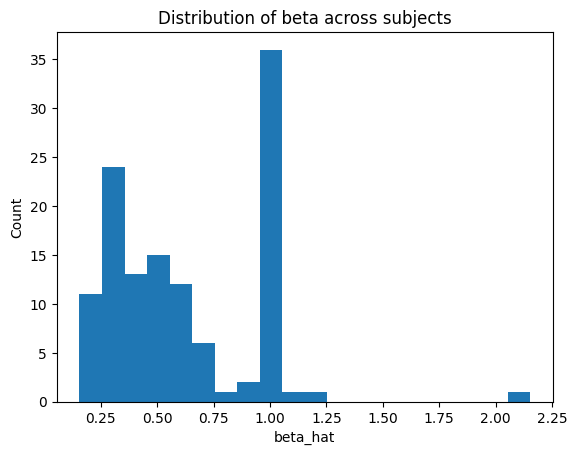

In [12]:
plt.figure()
plt.hist(df_out.groupby('sub_id')['beta_hat'].first(), bins=20)
plt.xlabel('beta_hat')
plt.ylabel('Count')
plt.title('Distribution of beta across subjects')
plt.show()

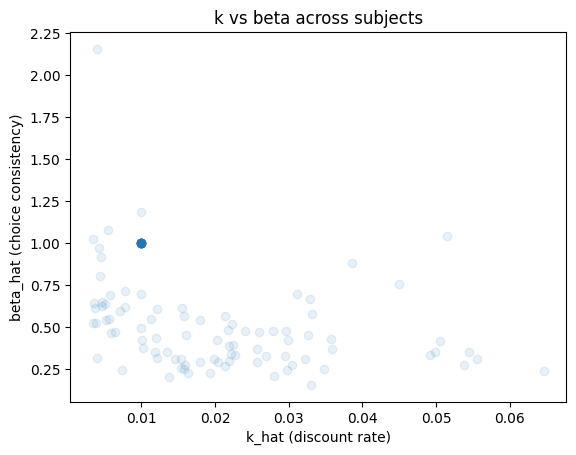

k_hat     beta_hat
0.010000  1.000000    33
0.003486  1.022050     1
0.003402  0.523336     1
0.003711  0.614568     1
0.003864  0.524687     1
0.004007  2.154491     1
0.004044  0.317152     1
0.004300  0.970065     1
0.004344  0.802923     1
0.004542  0.914598     1
Name: count, dtype: int64


In [25]:
sub_params = df_out.groupby('sub_id')[['k_hat', 'beta_hat']].first()

plt.figure()
plt.scatter(sub_params['k_hat'], sub_params['beta_hat'], alpha=0.1)
plt.xlabel('k_hat (discount rate)')
plt.ylabel('beta_hat (choice consistency)')
plt.title('k vs beta across subjects')
plt.show()

dup_counts = sub_params.value_counts()

print(dup_counts.head(10))

In [30]:
df_out.groupby('sub_id')['choseAccept'].mean().describe()

count    123.000000
mean       0.443216
std        0.214167
min        0.100000
25%        0.267752
50%        0.402299
75%        0.585749
max        0.866667
Name: choseAccept, dtype: float64

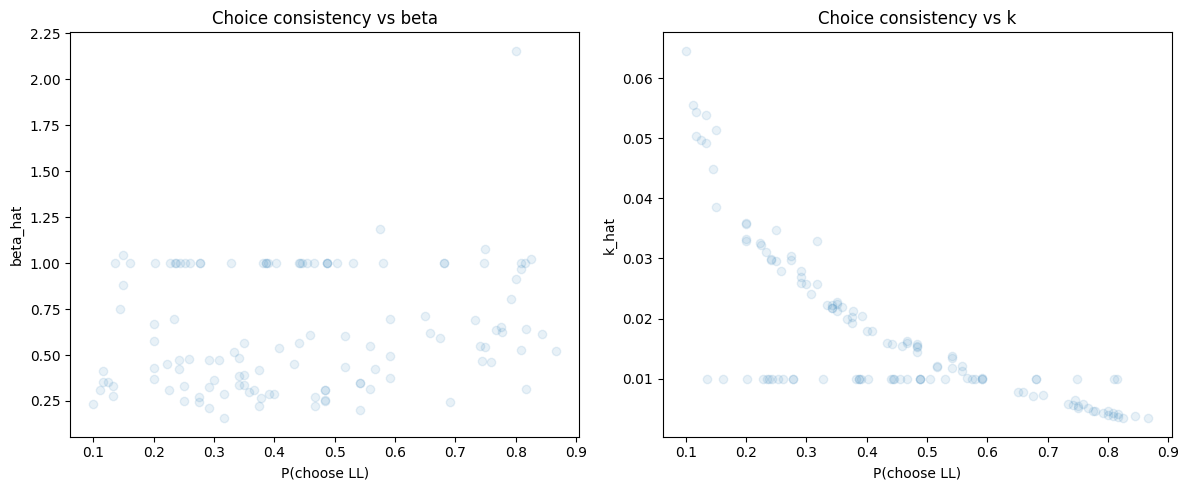

In [29]:
sub = (
    df_out.groupby('sub_id')
    .agg(
        k_hat=('k_hat', 'first'),
        beta_hat=('beta_hat', 'first'),
        p_choose_ll=('choseAccept', 'mean'),
        n_trials=('choseAccept', 'size'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --------------------------------------------------
# Panel 1: p(choose LL) vs beta
# --------------------------------------------------

axes[0].scatter(sub['p_choose_ll'], sub['beta_hat'], alpha=0.1)
axes[0].set_xlabel('P(choose LL)')
axes[0].set_ylabel('beta_hat')
axes[0].set_title('Choice consistency vs beta')

# --------------------------------------------------
# Panel 2: p(choose LL) vs k
# --------------------------------------------------

axes[1].scatter(sub['p_choose_ll'], sub['k_hat'], alpha=0.1)
axes[1].set_xlabel('P(choose LL)')
axes[1].set_ylabel('k_hat')
axes[1].set_title('Choice consistency vs k')

plt.tight_layout()
plt.show()

In [27]:
subject_params = df_out.groupby('sub_id')[['k_hat', 'beta_hat']].first()

print(subject_params.describe())

            k_hat    beta_hat
count  123.000000  123.000000
mean     0.017779    0.629476
std      0.013303    0.328284
min      0.003402    0.155634
25%      0.010000    0.343883
50%      0.011269    0.547573
75%      0.023388    1.000000
max      0.064571    2.154491


In [35]:
weird_ids = subject_params[
    (np.isclose(subject_params['k_hat'], 0.01, atol=1e-3))
    & (np.isclose(subject_params['beta_hat'], 1.0, atol=1e-3))
].index.tolist()

print(len(weird_ids), 'weird subjects')

33 weird subjects


In [46]:
sub_id = weird_ids[0]
df_sub = df_out[df_out['sub_id'] == sub_id].copy()
df_sub = df_sub.copy()

df_sub = df_sub.dropna(subset=['amount', 'Delay', 'choseAccept'])

df_sub['choseAccept'] = df_sub['choseAccept'].astype(int)
df_sub['amount'] = df_sub['amount'].astype(float)
df_sub['Delay'] = df_sub['Delay'].astype(float)
amount = df_sub['amount'].values
delay = df_sub['Delay'].values
choices = df_sub['choseAccept'].values

In [ ]:
SS_AMOUNT = 20


def neg_ll_grid(log_k, log_beta, amount, delay, choices):
    k = np.exp(log_k)
    beta = np.exp(log_beta)

    sv_ll = amount / (1 + k * delay)
    sv_ss = SS_AMOUNT

    p = expit(beta * (sv_ll - sv_ss))
    p = np.clip(p, 1e-10, 1 - 1e-10)

    ll = choices * np.log(p) + (1 - choices) * np.log(1 - p)
    return -np.sum(ll)

In [48]:
log_k_vals = np.linspace(np.log(0.001), np.log(0.2), 50)
log_beta_vals = np.linspace(np.log(0.1), np.log(10), 50)

LL_surface = np.zeros((len(log_k_vals), len(log_beta_vals)))

for i, lk in enumerate(log_k_vals):
    for j, lb in enumerate(log_beta_vals):
        LL_surface[i, j] = neg_ll_grid(lk, lb, amount, delay, choices)

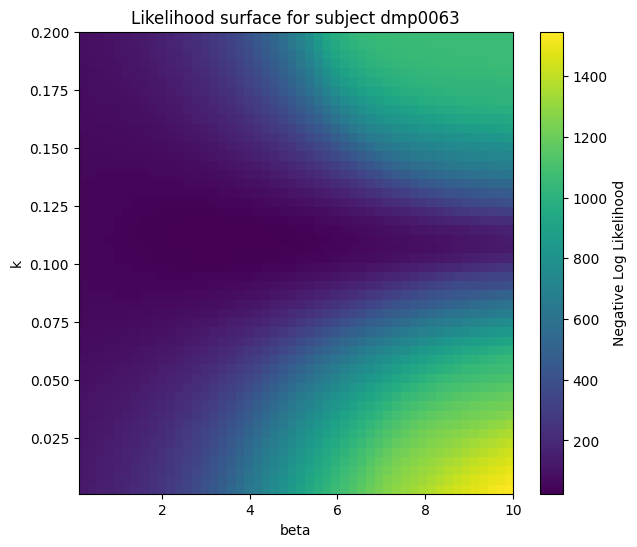

In [51]:
plt.figure(figsize=(7, 6))

plt.imshow(
    LL_surface,
    origin='lower',
    aspect='auto',
    extent=[
        np.exp(log_beta_vals[0]),
        np.exp(log_beta_vals[-1]),
        np.exp(log_k_vals[0]),
        np.exp(log_k_vals[-1]),
    ],
)

plt.colorbar(label='Negative Log Likelihood')
plt.xlabel('beta')
plt.ylabel('k')
plt.title(f'Likelihood surface for subject {sub_id}')

plt.show()

/tmp/ipykernel_16130/678146144.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df = tmp.groupby('delay_bin')['choose_LL'].mean()


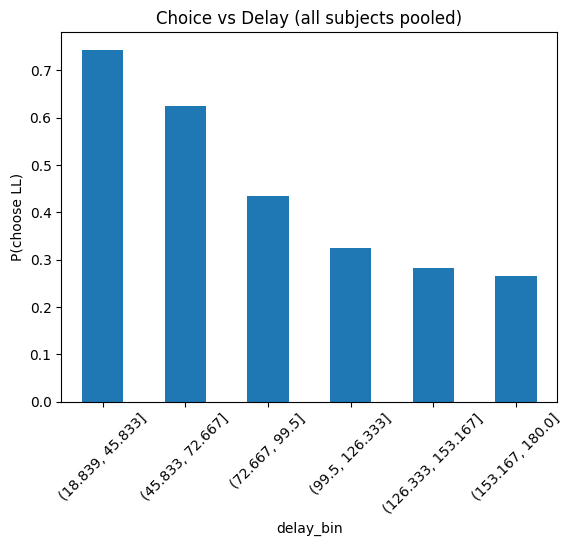

In [53]:
tmp = df_out.copy()
tmp = tmp.dropna(subset=['choseAccept', 'Delay', 'amount'])

tmp['choose_LL'] = tmp['choseAccept'].astype(int)

tmp['delay_bin'] = pd.cut(tmp['Delay'], bins=6)

plot_df = tmp.groupby('delay_bin')['choose_LL'].mean()

plt.figure()
plot_df.plot(kind='bar')
plt.ylabel('P(choose LL)')
plt.title('Choice vs Delay (all subjects pooled)')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_16130/3946058362.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df = df_sub.groupby('delay_bin')['choose_LL'].mean()


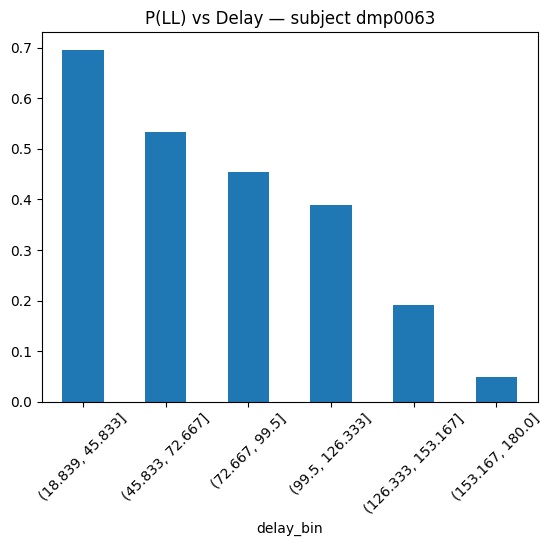

In [54]:
sub = weird_ids[0]
df_sub = df_out[df_out['sub_id'] == sub].copy()

df_sub = df_sub.dropna(subset=['choseAccept', 'Delay'])

df_sub['choose_LL'] = df_sub['choseAccept'].astype(int)
df_sub['delay_bin'] = pd.cut(df_sub['Delay'], bins=6)

plot_df = df_sub.groupby('delay_bin')['choose_LL'].mean()

plt.figure()
plot_df.plot(kind='bar')
plt.title(f'P(LL) vs Delay — subject {sub}')
plt.xticks(rotation=45)
plt.show()

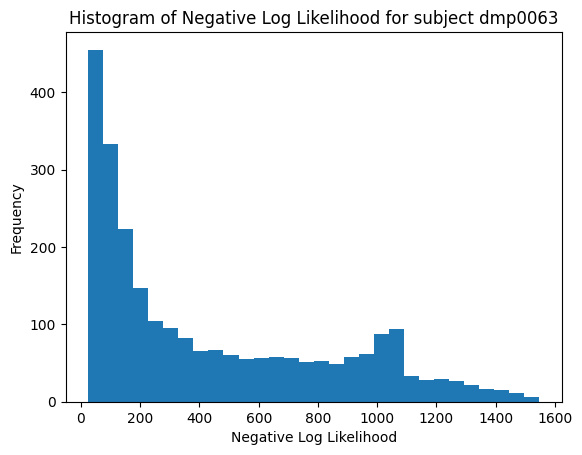

In [52]:
plt.hist(LL_surface.flatten(), bins=30)
plt.xlabel('Negative Log Likelihood')
plt.ylabel('Frequency')
plt.title(f'Histogram of Negative Log Likelihood for subject {sub_id}')
plt.show()

/tmp/ipykernel_16130/235755790.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df = tmp.groupby(delay_bins)['choose_ll'].mean()


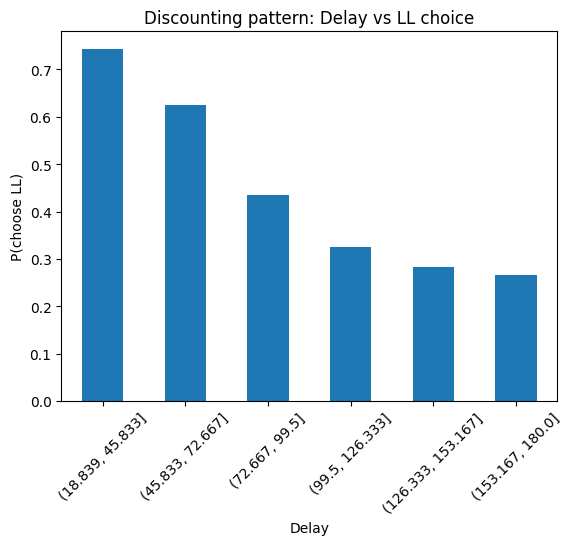

In [20]:
tmp = df_out.copy()

tmp = tmp.dropna(subset=['choseAccept'])

tmp['choose_ll'] = tmp['choseAccept'].astype(int)
delay_bins = pd.cut(tmp['Delay'], bins=6)

plot_df = tmp.groupby(delay_bins)['choose_ll'].mean()

plt.figure()
plot_df.plot(kind='bar')
plt.ylabel('P(choose LL)')
plt.title('Discounting pattern: Delay vs LL choice')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_16130/1888947675.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df = tmp.groupby('DV_bin')['choseAccept'].mean()


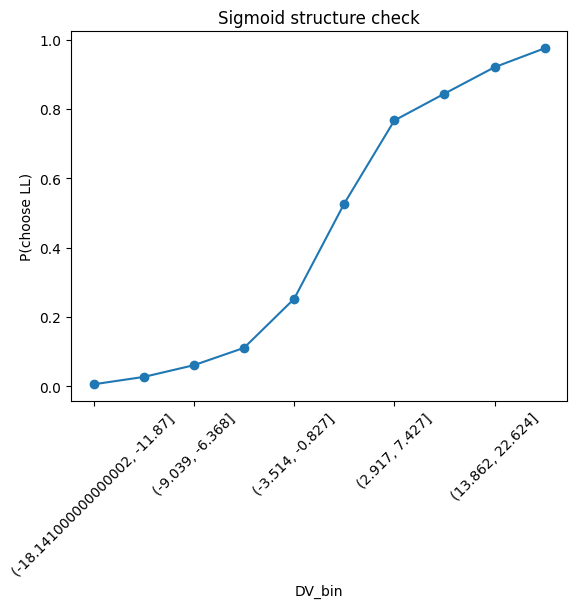

In [15]:
tmp['DV_bin'] = pd.qcut(tmp['DV'], 10)

plot_df = tmp.groupby('DV_bin')['choseAccept'].mean()

plt.figure()
plot_df.plot(marker='o')
plt.xticks(rotation=45)
plt.ylabel('P(choose LL)')
plt.title('Sigmoid structure check')
plt.show()

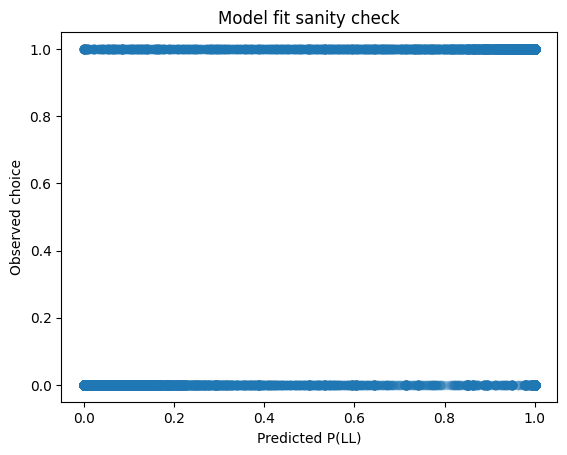

In [ ]:
df_out['p_choose_ll'] = expit(df_out['beta_hat'] * df_out['DV'])

plt.figure()
plt.scatter(df_out['p_choose_ll'], df_out['choseAccept'], alpha=0.2)
plt.xlabel('Predicted P(LL)')
plt.ylabel('Observed choice')
plt.title('Model fit sanity check')
plt.show()

/tmp/ipykernel_16130/2221423959.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = df_out.groupby('prob_bin')['choseAccept'].mean()


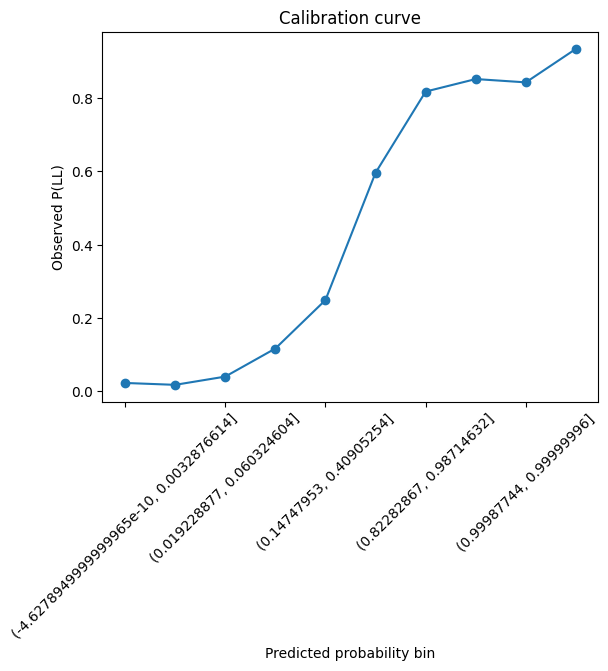

In [17]:
df_out['prob_bin'] = pd.qcut(df_out['p_choose_ll'], 10)

calib = df_out.groupby('prob_bin')['choseAccept'].mean()

plt.figure()
calib.plot(marker='o')
plt.xlabel('Predicted probability bin')
plt.ylabel('Observed P(LL)')
plt.title('Calibration curve')
plt.xticks(rotation=45)
plt.show()

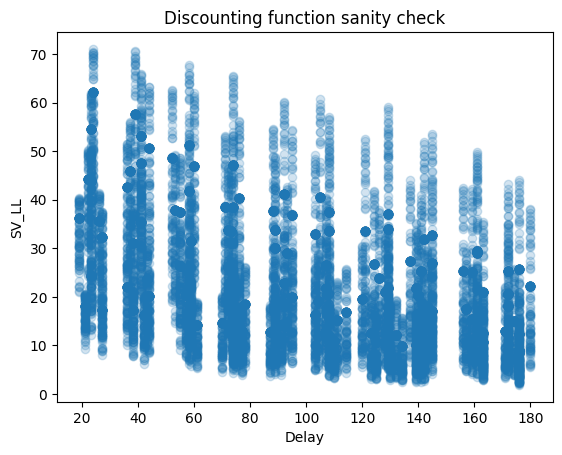

In [ ]:
# expect: downward curve with noise

plt.figure()
plt.scatter(df_out['Delay'], df_out['SV_LL'], alpha=0.2)
plt.xlabel('Delay')
plt.ylabel('SV_LL')
plt.title('Discounting function sanity check')
plt.show()

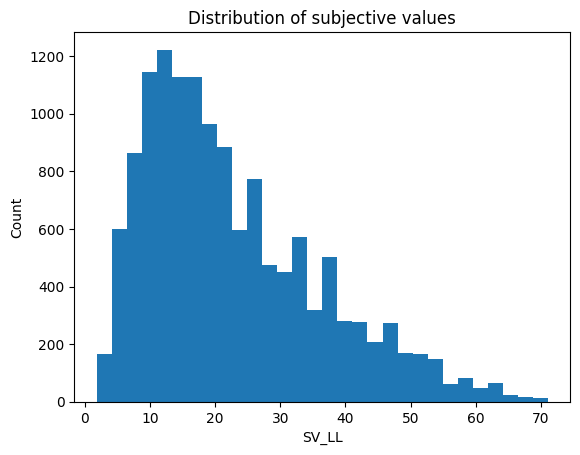

In [19]:
plt.figure()
plt.hist(df_out['SV_LL'], bins=30)
plt.xlabel('SV_LL')
plt.ylabel('Count')
plt.title('Distribution of subjective values')
plt.show()